# Two time-explicit modelling paradigms for EVs — explicit process/product in `bw_timex`

A small companion to the
[full fleet example](./example_electric_vehicle_fleet_explicit_process_product.ipynb).
It drops `flodym`, `scipy` and the bill-of-materials and keeps only what is
needed to contrast **two ways of asking a time-explicit question about EVs** —
the difference being entirely in *what you demand* and *how you set up the
relative `TemporalDistribution`s (RTDs) on the edges*:

- **Paradigm A — model one EV's life cycle.** The functional unit is *a vehicle*.
  RTDs on the vehicle's edges say *when* each exchange happens relative to the
  build: electricity spread over the driving years, disposal at end of life.
- **Paradigm B — demand the driving.** The functional unit is the *service*
  (vehicle-km). We split the vehicle into its **embodied** part (built earlier,
  backcast over the fleet's age mix) and its **driving electricity** (consumed at
  the moment the km is driven), and apply the **vintage efficiency through a
  `temporal_evolution` factor**.

Both use the same explicit setup: a **product node**
(`type=bd.labels.product_node_default`) is a bare *thing* you can demand; a
**process node** (`type=bd.labels.process_node_default`) owns all the edges and
points at its product via one production edge.

> Fully reproducible — only needs `bw_timex`, `bw_temporalis`,
> `dynamic_characterization`, `numpy`, `matplotlib`. Tiny made-up background
> databases stand in for ecoinvent/premise.

## Project and background databases

One CO2 biosphere flow and two time-stamped backgrounds (2025, 2045). `bw_timex`
interpolates between them, so any year in between gets a blended grid. Every
background process emits only CO2, and emissions fall over time — a decarbonising
world.

In [1]:
from datetime import datetime

import bw2data as bd
import numpy as np
import matplotlib.pyplot as plt
from bw_temporalis import TemporalDistribution
from bw_timex import TimexLCA

bd.projects.set_current("ev_single_to_fleet_explicit")
for db in list(bd.databases):
    del bd.databases[db]
for m in list(bd.methods):
    del bd.methods[m]

bd.Database("biosphere").write(
    {("biosphere", "CO2"): {"type": "emission", "name": "CO2", "unit": "kg"}}
)

# kg CO2 per unit, in (2025, 2045)
background_emissions = {
    "electricity":   (0.40, 0.05),   # per kWh
    "manufacturing": (6_000, 4_000), # per vehicle built
    "battery_eol":   (400, 200),     # per vehicle disposed
}
units = {"electricity": "kWh", "manufacturing": "vehicle", "battery_eol": "vehicle"}

for year_idx, db_name in [(0, "background_2025"), (1, "background_2045")]:
    bd.Database(db_name).write(
        {
            (db_name, code): {
                "name": code,
                "reference product": code,
                "unit": units[code],
                "location": "GLO",
                "exchanges": [
                    {"amount": 1, "type": "production", "input": (db_name, code)},
                    {"amount": emis[year_idx], "type": "biosphere", "input": ("biosphere", "CO2")},
                ],
            }
            for code, emis in background_emissions.items()
        }
    )

bd.Method(("GWP", "100")).write([(("biosphere", "CO2"), 1.0)])
method = ("GWP", "100")

database_dates = {
    "background_2025": datetime(2025, 1, 1),
    "background_2045": datetime(2045, 1, 1),
    "foreground": "dynamic",
}


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 8322.03it/s]

16:03:12+0200 [info     ] Vacuuming database            



  0%|          | 0/3 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00, 41120.63it/s]

16:03:12+0200 [info     ] Vacuuming database            



  0%|          | 0/3 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00, 53317.42it/s]

16:03:12+0200 [info     ] Vacuuming database            


### Plot helpers

`waterfall` draws the per-year stacked waterfall of the dynamically characterized
(GWP100) inventory (stacks ordered manufacturing → electricity → end-of-life);
`stage_inventory` groups it into those three life-cycle stages by calendar year.

In [2]:
from dynamic_characterization.ipcc_ar6 import characterize_co2
from bw_timex.utils import plot_characterized_inventory_as_waterfall

characterization_functions = {bd.get_activity(("biosphere", "CO2")).id: characterize_co2}

STAGE_ORDER  = ["manufacturing", "electricity (use)", "end-of-life"]
STAGE_COLORS = {"manufacturing": "#9c5ffd", "electricity (use)": "#3fb1c5", "end-of-life": "#dd5b5b"}

def _stage(label):
    l = label.lower()
    if "manufactur" in l: return "manufacturing"
    if "electric"  in l: return "electricity (use)"
    if "eol"       in l: return "end-of-life"
    return "other"

def _named_inventory(tlca):
    tlca.dynamic_lcia(metric="GWP", time_horizon=100,
                      characterization_functions=characterization_functions)
    df = tlca.characterized_inventory.copy()
    df["year"] = df["date"].dt.year
    names = {i: tlca.get_activity_name_from_time_mapped_id(i) for i in df["activity"].unique()}
    df["name"] = df["activity"].map(names)
    return df

def _stack_order(names):
    rank = {"manufactur": 0, "electric": 1, "eol": 2}
    def key(n):
        for k, r in rank.items():
            if k in n.lower():
                return r
        return 3
    return sorted(names, key=key)

def waterfall(tlca):
    names = list(_named_inventory(tlca)["name"].unique())   # also runs dynamic_lcia
    plot_characterized_inventory_as_waterfall(
        tlca, order_stacked_activities=_stack_order(names)
    )

def stage_inventory(tlca):
    df = _named_inventory(tlca)
    df["stage"] = df["name"].map(_stage)
    table = df.groupby(["year", "stage"])["amount"].sum().unstack(fill_value=0)
    return table.reindex(columns=[s for s in STAGE_ORDER if s in table.columns], fill_value=0)

## Per-vehicle assumptions and a quick RTD primer

A few per-vehicle numbers, and the relative `TemporalDistribution`s we hang on
edges.

**What an RTD is.** `TemporalDistribution(date, amount)` distributes one exchange
across time. On an edge `date` is **relative** (`timedelta64`): `+1y` = a year
*after* the owning process, `-1y` = a year *before* (a backcast, used in Paradigm
B). Weights (`amount`) sum to 1; magnitude lives on the edge `amount`. Attach
with `temporal_distribution=...`. No RTD = a point at the process's own time.

In [3]:
ANNUAL_MILEAGE = 12_000        # km / year
ELEC_PER_KM    = 0.20          # kWh / km (2025 baseline)
LIFETIME_YEARS = 12
LIFETIME_KWH   = ANNUAL_MILEAGE * ELEC_PER_KM * LIFETIME_YEARS
LIFETIME_KM    = ANNUAL_MILEAGE * LIFETIME_YEARS   # total km one vehicle drives

ages = np.arange(0, LIFETIME_YEARS)

# Use phase: electricity spread evenly over the driving years (weights sum to 1).
td_use_age = TemporalDistribution(
    date=ages.astype("timedelta64[Y]"),
    amount=np.full(LIFETIME_YEARS, 1 / LIFETIME_YEARS),
)
# End-of-life: a single disposal event at the end of life.
td_eol_age = TemporalDistribution(
    date=np.array([LIFETIME_YEARS], dtype="timedelta64[Y]"),
    amount=np.array([1.0]),
)

# Paradigm A — Model one EV's life cycle

Functional unit: **a vehicle**. One product, one process; the RTDs place its
edges in time.

```mermaid
flowchart LR
    mfg(manufacturing):::bg -->|no RTD = at build| evlc
    elec(electricity):::bg -->|td_use_age| evlc
    evlc("ev_lifecycle"):::fg -->|production edge| ev([ev]):::product
    evlc -->|td_eol_age| eol(battery_eol):::bg
    classDef fg color:#222832, fill:#3fb1c5, stroke:none;
    classDef product color:#222832, fill:#9c5ffd, stroke:none;
    classDef bg color:#222832, fill:#3fb1c5, stroke:none;
```

- **manufacturing** — no RTD → a point at the build year;
- **electricity** — `td_use_age` → lifetime kWh over the 12 driving years;
- **battery_eol** — `td_eol_age` → disposal at age 12.

In [4]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

ev = foreground.new_node(
    code="ev", name="EV (vehicle-lifetime)", unit="vehicle-lifetime",
    location="GLO", type=bd.labels.product_node_default,
)
ev.save()
ev_lifecycle = foreground.new_node(
    code="ev_lifecycle", name="EV life cycle (per vehicle)", unit="vehicle-lifetime",
    location="GLO", type=bd.labels.process_node_default,
)
ev_lifecycle.save()

ev_lifecycle.new_edge(input=ev, amount=1, type=bd.labels.production_edge_default).save()
ev_lifecycle.new_edge(
    input=bd.get_node(database="background_2025", code="manufacturing"),
    amount=1, type=bd.labels.consumption_edge_default,
).save()
ev_lifecycle.new_edge(
    input=bd.get_node(database="background_2025", code="electricity"),
    amount=LIFETIME_KWH, type=bd.labels.consumption_edge_default,
    temporal_distribution=td_use_age,
).save()
ev_lifecycle.new_edge(
    input=bd.get_node(database="background_2025", code="battery_eol"),
    amount=1, type=bd.labels.consumption_edge_default,
    temporal_distribution=td_eol_age,
).save()

for db in bd.databases:
    bd.Database(db).process()

Demand one vehicle, anchored at its build year. The waterfall shows the
manufacturing spike at the build year, a declining tail of use-phase electricity
(the grid cleans up as the car ages), and a disposal blip at end of life.

2026-06-05 16:03:12.104 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...


2026-06-05 16:03:12.104 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...


2026-06-05 16:03:12.113 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...


2026-06-05 16:03:12.116 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.


2026-06-05 16:03:12.116 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...


2026-06-05 16:03:12.117 | INFO     | bw_timex.timeline_builder:__init__:104 - Traversing supply chain graph...


2026-06-05 16:03:12.123 | INFO     | bw_timex.timeline_builder:build_timeline:163 - Building timeline...


2026-06-05 16:03:12.139 | INFO     | bw_timex.timex_lca:lci:471 - Expanding matrices...


2026-06-05 16:03:12.147 | INFO     | bw_timex.timex_lca:lci:490 - Calculating dynamic inventory...


Starting graph traversal
Calculation count: 3
One EV built in 2025:
  Static (2025 grid) :     17,920 kg CO2-eq
  Time-explicit      :     15,028 kg CO2-eq


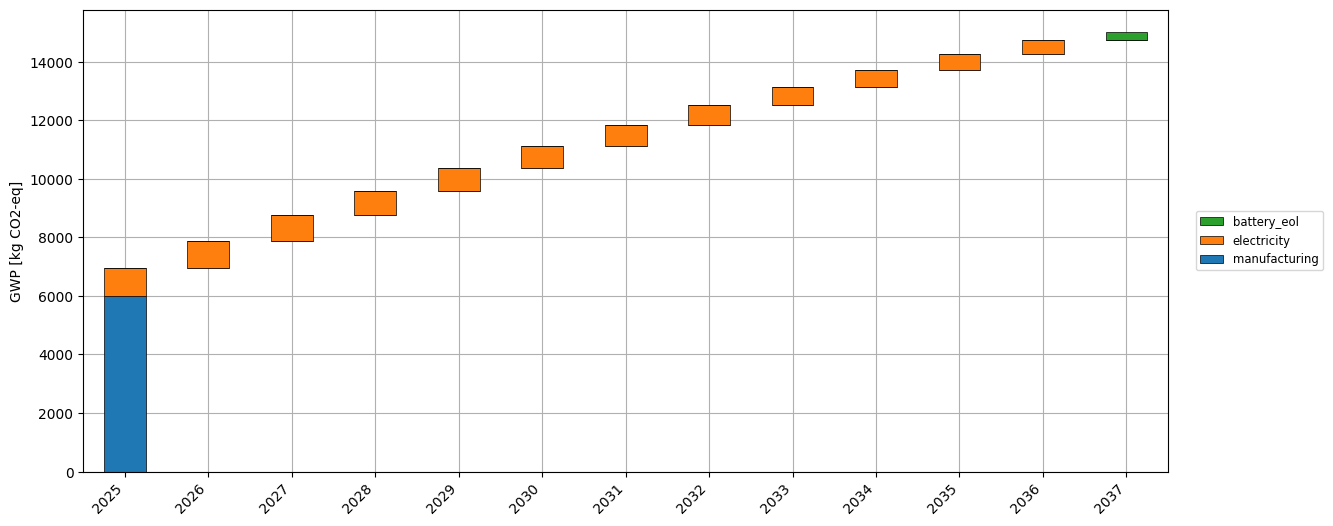

In [5]:
tlca_A = TimexLCA(demand={ev: 1}, method=method, database_dates=database_dates)
tlca_A.build_timeline(starting_datetime=datetime(2025, 1, 1), temporal_grouping="year")
tlca_A.lci()
tlca_A.static_lcia()

print("One EV built in 2025:")
print(f"  Static (2025 grid) : {tlca_A.base_lca.score:>10,.0f} kg CO2-eq")
print(f"  Time-explicit      : {tlca_A.static_score:>10,.0f} kg CO2-eq")

waterfall(tlca_A)

# Paradigm B — Demand the driving

Functional unit: the **driving service** (vehicle-km). In Paradigm A the
electricity was bundled into the vehicle and spread over the vehicle's own life —
right for a *vehicle* unit. For a *driving* unit it would be wrong: the
electricity for a km driven in 2037 should be consumed **in 2037**, on 2037's
grid, not smeared across the twelve years of whatever vehicle drove it. So we
**split the vehicle to match the functional unit**:

- **`ev_production`** — the **embodied** burden only (manufacturing + end-of-life),
  producing a bare product `vehicle`.
- **`driving`** — produces `km_driven`, and consumes:
  - **electricity** per km, **at the drive year** (no RTD → it happens when the km
    is driven);
  - a `1/LIFETIME_KM` share of `vehicle` via a **backward** age RTD — the vehicle
    that drove this km was *built earlier*.

```mermaid
flowchart LR
    mfg(manufacturing):::bg -->|at build| evp
    eol(battery_eol):::bg -->|EOL RTD| evp
    evp("ev_production"):::fg -->|production edge| veh([vehicle]):::product
    veh -->|backward age RTD<br/>1 per lifetime-km| drv
    elec(electricity):::bg -->|at drive year<br/>fleet efficiency| drv
    drv("driving"):::fg -->|production edge| km([km_driven]):::product
    classDef fg color:#222832, fill:#3fb1c5, stroke:none;
    classDef product color:#222832, fill:#9c5ffd, stroke:none;
    classDef bg color:#222832, fill:#3fb1c5, stroke:none;
```

The new RTD is the **backward age** one — same ages as `td_use_age`, but with
*negative* offsets, shaped as a **normal distribution over age** (the fleet age
mix: most km are driven by mid-aged vehicles). On the `driving → vehicle` edge it
says: *a km demanded in year Y was driven by vehicles built in Y, Y-1, …,
Y-(L-1)*, so the embodied burden backcasts over those build years.

**Vintage efficiency — through the evolution factor.** Each vintage keeps its
build-year kWh/km (locked). The electricity, though, is a single edge consumed at
the drive year, so we apply the **fleet-average efficiency of the vintages on the
road that year** — `Σ_age (age-mix weight) · f(Y - age)` — as a
`temporal_evolution` factor with `reference="producer"`. It is a genuine average
that *varies by draw year* (older vintages age out as Y advances). We don't
resolve the electricity by individual vintage in the inventory — that would need
one process per vintage; here we deliberately keep a single electricity edge and
carry the vintage effect through the evolution factor only.

## Setting up the split: `ev_production` + `driving`

In [6]:
# Backward age RTD: fleet age mix as a NORMAL distribution over age (negative
# offsets -> the vehicle was built earlier than the km it drives).
AGE_MEAN, AGE_STD = 5.5, 2.5
w_age = np.exp(-0.5 * ((ages - AGE_MEAN) / AGE_STD) ** 2)
w_age /= w_age.sum()
td_age_back = TemporalDistribution(
    date=(-ages).astype("timedelta64[Y]"), amount=w_age,
)

# --- Embodied vehicle: manufacturing (@build) + end-of-life (@build + L). ---
vehicle = foreground.new_node(
    code="vehicle", name="EV (embodied: production + disposal)", unit="vehicle",
    location="GLO", type=bd.labels.product_node_default,
)
vehicle.save()
ev_production = foreground.new_node(
    code="ev_production", name="EV production (embodied)", unit="vehicle",
    location="GLO", type=bd.labels.process_node_default,
)
ev_production.save()
ev_production.new_edge(input=vehicle, amount=1, type=bd.labels.production_edge_default).save()
ev_production.new_edge(
    input=bd.get_node(database="background_2025", code="manufacturing"),
    amount=1, type=bd.labels.consumption_edge_default,
).save()
ev_production.new_edge(
    input=bd.get_node(database="background_2025", code="battery_eol"),
    amount=1, type=bd.labels.consumption_edge_default,
    temporal_distribution=td_eol_age,
).save()

# --- Driving service: electricity at the drive year + an embodied share. ---
km_driven = foreground.new_node(
    code="km_driven", name="EV driving (vehicle-km)", unit="km",
    location="GLO", type=bd.labels.product_node_default,
)
km_driven.save()
driving = foreground.new_node(
    code="driving", name="EV driving (per km)", unit="km",
    location="GLO", type=bd.labels.process_node_default,
)
driving.save()
driving.new_edge(input=km_driven, amount=1, type=bd.labels.production_edge_default).save()
# Electricity: one edge, consumed at the drive year (no RTD).
driving.new_edge(
    input=bd.get_node(database="background_2025", code="electricity"),
    amount=ELEC_PER_KM, type=bd.labels.consumption_edge_default,
).save()
# Embodied: 1/LIFETIME_KM of a vehicle, built earlier (backward age RTD).
driving.new_edge(
    input=vehicle, amount=1 / LIFETIME_KM, type=bd.labels.consumption_edge_default,
    temporal_distribution=td_age_back,
).save()

# --- Vintage efficiency -> fleet-average kWh/km on the road each draw year,
# applied as a producer-ref temporal_evolution factor on the single elec edge. ---
vintage_efficiency_factors = {2025: 1.00, 2035: 0.85, 2045: 0.75}  # kWh/km vs 2025, by build year
def vintage_factor(year):
    yrs = np.array(sorted(vintage_efficiency_factors))
    vals = np.array([vintage_efficiency_factors[y] for y in yrs])
    return float(np.interp(year, yrs, vals))

# Average over the vintages on the road in year y, weighted by the age mix
# (the same weights as td_age_back) -> varies by year, not a fixed value.
fleet_efficiency_by_year = {
    datetime(int(y), 1, 1): float(
        np.sum(td_age_back.amount * np.array([vintage_factor(y - a) for a in ages]))
    )
    for y in range(2025, 2056)
}

elec_edge = next(
    exc for exc in driving.technosphere() if exc.input["name"] == "electricity"
)
elec_edge["temporal_evolution_factors"] = fleet_efficiency_by_year
elec_edge["temporal_evolution_reference"] = "producer"   # evaluated at the drive year
elec_edge.save()
bd.Database("foreground").process()

## Demand **1 km of driving in one year**

One vehicle-km, driven in **2037**. The first plot is the backward age RTD mapped
to build years — the fleet age mix the km is attributed to. The waterfall then
shows: **electricity in 2037 only** (consumed at the drive year), **manufacturing**
backcast over 2026–2037 (the cohorts that served it), **end-of-life** trailing.

2026-06-05 16:03:12.328 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...


2026-06-05 16:03:12.328 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...


2026-06-05 16:03:12.335 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...


2026-06-05 16:03:12.339 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.


2026-06-05 16:03:12.340 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...


...

2026-06-05 16:03:12.351 | INFO     | bw_timex.timeline_builder:build_timeline:163 - Building timeline...


2026-06-05 16:03:12.359 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:622 - Reference date 2046-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-06-05 16:03:12.367 | INFO     | bw_timex.timex_lca:lci:471 - Expanding matrices...


2026-06-05 16:03:12.387 | INFO     | bw_timex.timex_lca:lci:490 - Calculating dynamic inventory...


Starting graph traversal
Calculation count: 4
Footprint of 1 vehicle-km driven in 2037:
  Static (2025 grid)             :   0.1244 kg CO2-eq
  Time-explicit (grid + vintages):   0.0730 kg CO2-eq


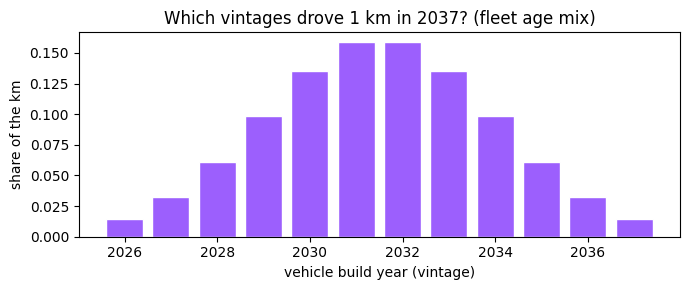

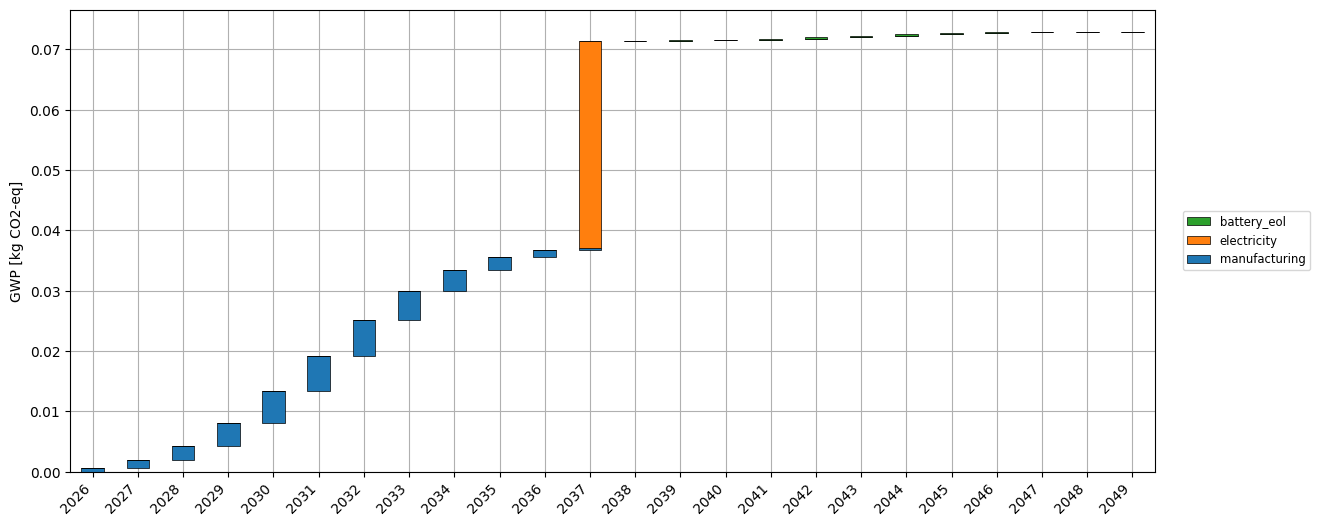

In [7]:
DRIVE_YEAR = 2037
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(DRIVE_YEAR - ages, td_age_back.amount, color="#9c5ffd", edgecolor="white")
ax.set(xlabel="vehicle build year (vintage)", ylabel="share of the km",
       title=f"Which vintages drove 1 km in {DRIVE_YEAR}? (fleet age mix)")
fig.tight_layout()

tlca_1km = TimexLCA(demand={km_driven: 1}, method=method, database_dates=database_dates)
tlca_1km.build_timeline(starting_datetime=datetime(DRIVE_YEAR, 1, 1), temporal_grouping="year")
tlca_1km.lci()
tlca_1km.static_lcia()

print(f"Footprint of 1 vehicle-km driven in {DRIVE_YEAR}:")
print(f"  Static (2025 grid)             : {tlca_1km.base_lca.score:>8.4f} kg CO2-eq")
print(f"  Time-explicit (grid + vintages): {tlca_1km.static_score:>8.4f} kg CO2-eq")

waterfall(tlca_1km)

## Scale up to a fleet

Demand a smooth driving curve (vehicle-km per year). Electricity tracks the
driving directly (each year, on that year's grid, at the fleet-average vintage
efficiency); manufacturing runs ahead of it; end-of-life trails behind.

2026-06-05 16:03:12.641 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...


2026-06-05 16:03:12.642 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...


2026-06-05 16:03:12.650 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...


2026-06-05 16:03:12.655 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.


2026-06-05 16:03:12.656 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...


...

2026-06-05 16:03:12.697 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:622 - Reference date 2046-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-06-05 16:03:12.709 | INFO     | bw_timex.timex_lca:lci:471 - Expanding matrices...


Starting graph traversal
Calculation count: 4


2026-06-05 16:03:12.973 | INFO     | bw_timex.timex_lca:lci:490 - Calculating dynamic inventory...


Total driving demanded: 49 million vehicle-km
  Static (2025 grid)             :  6,125,775 kg CO2-eq
  Time-explicit (grid + vintages):  2,852,250 kg CO2-eq


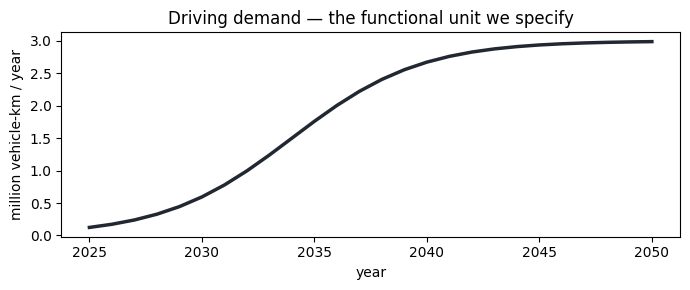

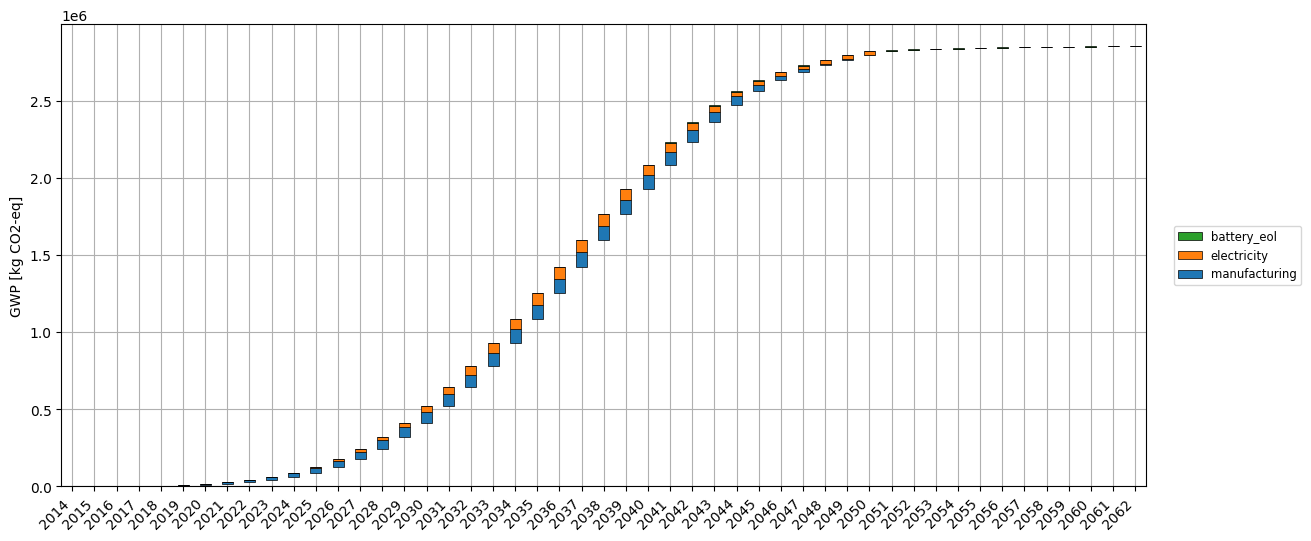

In [8]:
years = np.arange(2025, 2051)
driving_demand_km = 3.0e6 / (1 + np.exp(-0.35 * (years - 2034)))
km_demand = TemporalDistribution(
    date=np.array([datetime(int(y), 1, 1) for y in years], dtype="datetime64[s]"),
    amount=driving_demand_km,
)

def run_km(use_efficiency=True):
    """Run the fleet, optionally applying the fleet-average vintage efficiency."""
    for key in ("temporal_evolution_factors", "temporal_evolution_reference"):
        try:
            del elec_edge[key]
        except KeyError:
            pass
    if use_efficiency:
        elec_edge["temporal_evolution_factors"] = fleet_efficiency_by_year
        elec_edge["temporal_evolution_reference"] = "producer"
    elec_edge.save()
    bd.Database("foreground").process()
    t = TimexLCA(demand={km_driven: km_demand}, method=method, database_dates=database_dates)
    t.build_timeline(starting_datetime=datetime(2025, 1, 1), temporal_grouping="year")
    t.lci()
    t.static_lcia()
    return t

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.plot(years, driving_demand_km / 1e6, color="#222832", lw=2.5)
ax.set(xlabel="year", ylabel="million vehicle-km / year",
       title="Driving demand — the functional unit we specify")
fig.tight_layout()

tlca_B = run_km(use_efficiency=True)
print(f"Total driving demanded: {driving_demand_km.sum() / 1e6:,.0f} million vehicle-km")
print(f"  Static (2025 grid)             : {tlca_B.base_lca.score:>10,.0f} kg CO2-eq")
print(f"  Time-explicit (grid + vintages): {tlca_B.static_score:>10,.0f} kg CO2-eq")

waterfall(tlca_B)

Same thing by life-cycle stage: **manufacturing** ahead (the backward RTD),
**electricity** the broad use-phase block, **end-of-life** trailing.

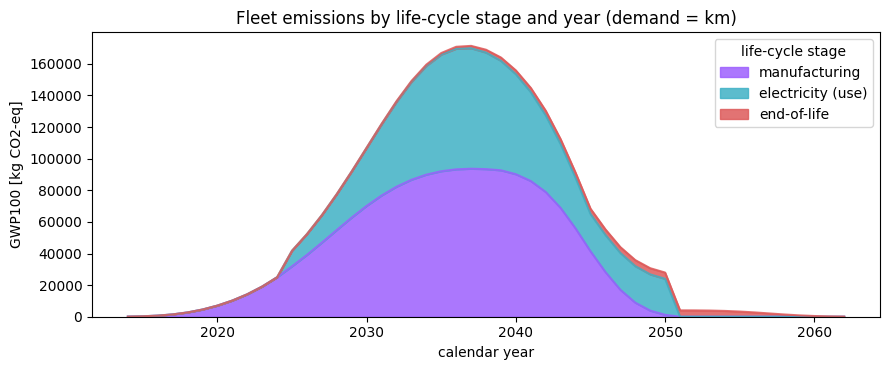

In [9]:
fleet_stages = stage_inventory(tlca_B)
ax = fleet_stages.plot.area(
    figsize=(9, 3.8), color=[STAGE_COLORS[c] for c in fleet_stages.columns], alpha=0.85,
)
ax.set(xlabel="calendar year", ylabel="GWP100 [kg CO2-eq]",
       title="Fleet emissions by life-cycle stage and year (demand = km)")
ax.legend(title="life-cycle stage", loc="upper right")
plt.tight_layout()

## What the vintage efficiency buys

Each vintage is locked to its build-year kWh/km; on the road, the fleet's
*average* efficiency improves as newer, thriftier vintages replace older ones.
The left plot is that fleet-average curve (weighted by the age mix → it drifts
down over time, not a fixed number). The right compares cumulative fleet
emissions with and without the evolution factor — the gap is the use-phase saving
from fleet renewal, on top of grid decarbonisation.

2026-06-05 16:03:13.564 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...


2026-06-05 16:03:13.565 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...


2026-06-05 16:03:13.571 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...


2026-06-05 16:03:13.574 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.


2026-06-05 16:03:13.575 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...


...

2026-06-05 16:03:14.273 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:622 - Reference date 2046-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-06-05 16:03:14.282 | INFO     | bw_timex.timex_lca:lci:471 - Expanding matrices...


Starting graph traversal
Calculation count: 4


2026-06-05 16:03:14.548 | INFO     | bw_timex.timex_lca:lci:490 - Calculating dynamic inventory...


No vintage evolution (2025 kWh/km):  2,985,686 kg CO2-eq
With vintage evolution            :  2,852,250 kg CO2-eq (-4.5%)


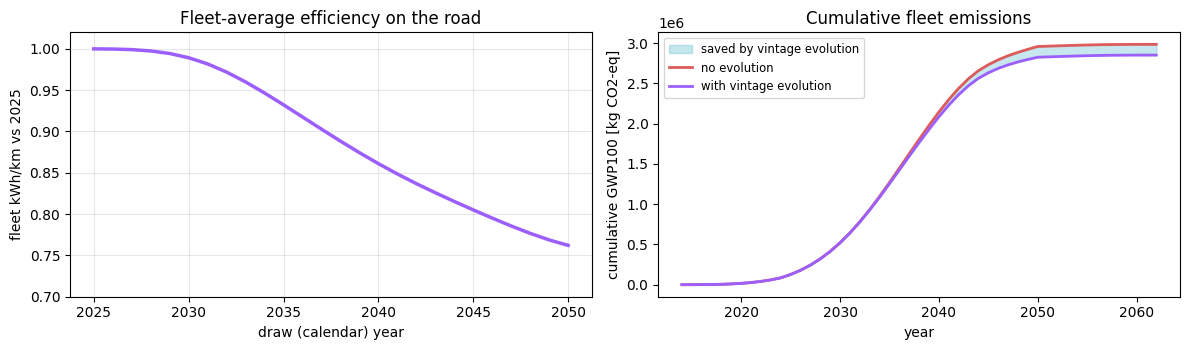

In [10]:
tlca_B_no_evo = run_km(use_efficiency=False)
tlca_B        = run_km(use_efficiency=True)   # restore default

print(f"No vintage evolution (2025 kWh/km): {tlca_B_no_evo.static_score:>10,.0f} kg CO2-eq")
print(f"With vintage evolution            : {tlca_B.static_score:>10,.0f} kg CO2-eq "
      f"({100 * (tlca_B.static_score - tlca_B_no_evo.static_score) / tlca_B_no_evo.static_score:+.1f}%)")

def yearly(tl):
    d = tl.create_dynamic_inventory_dataframe()
    d["year"] = d["date"].dt.year
    return d.groupby("year")["amount"].sum()

y_with    = yearly(tlca_B)
y_without = yearly(tlca_B_no_evo)
idx = sorted(set(y_with.index) | set(y_without.index))
y_with    = y_with.reindex(idx, fill_value=0).cumsum()
y_without = y_without.reindex(idx, fill_value=0).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
eff_years = sorted(fleet_efficiency_by_year)
eff_years = [d for d in eff_years if 2025 <= d.year <= 2050]
axes[0].plot([d.year for d in eff_years],
             [fleet_efficiency_by_year[d] for d in eff_years],
             color="#9c5ffd", lw=2.5)
axes[0].set(xlabel="draw (calendar) year", ylabel="fleet kWh/km vs 2025",
            title="Fleet-average efficiency on the road", ylim=(0.7, 1.02))
axes[0].grid(alpha=0.3)

axes[1].fill_between(idx, y_without, y_with, color="#3fb1c5", alpha=0.3,
                     label="saved by vintage evolution")
axes[1].plot(idx, y_without, color="#dd5b5b", lw=2, label="no evolution")
axes[1].plot(idx, y_with,    color="#9c5ffd", lw=2, label="with vintage evolution")
axes[1].set(xlabel="year", ylabel="cumulative GWP100 [kg CO2-eq]",
            title="Cumulative fleet emissions")
axes[1].legend(loc="upper left", fontsize="small")
fig.tight_layout()

# Wrap-up — the two paradigms side by side

| | **Paradigm A — one EV life cycle** | **Paradigm B — demand the driving** |
|---|---|---|
| Functional unit | a vehicle (`{ev: 1}`) | driving service (`{km_driven: TD(km/year)}`) |
| Electricity RTD | `td_use_age` — spread over the vehicle's own life | none — consumed **at the drive year** |
| Embodied timing | at the build year (point) | **backcast** via `td_age_back` (a normal age mix) |
| Efficiency | per-vehicle, at build | fleet-average of on-road vintages, via `temporal_evolution` |
| Scale to fleet | demand many vehicle-lifetimes (cohorts) | demand a km/year curve |

Takeaways:

- **The functional unit decides the split and the RTDs.** A *vehicle* unit
  bundles electricity over the vehicle's life; a *driving* unit splits it off so
  each km is charged at the drive year, and backcasts the embodied burden over
  the fleet age mix.
- **RTD direction is the lever.** Forward offsets push an exchange later than the
  process (use, disposal); negative offsets cast it earlier (built before driven).
- **Vintage efficiency rides the evolution factor.** With a single electricity
  edge consumed at the drive year, the vintage effect enters as the year-varying
  fleet-average (`reference="producer"`). The trade-off: the electricity can't be
  resolved by individual vintage in the inventory — that would need one process
  per vintage. Here we keep it simple and accept the aggregate.

From here the [full fleet notebook](./example_electric_vehicle_fleet_explicit_process_product.ipynb)
adds the realistic pieces: a bill-of-materials, a Weibull lifetime that spreads
each cohort's retirements, and `flodym` to produce a stock-driven inflow and a
real, year-varying age structure instead of the fixed normal used here.